In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Total Rows: 569
Total Columns: 33
Features: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']
Test Accuracy: 0.8947368421052632
Test Accuracy (%): 89.47368421052632
Train Accuracy: 0.9230769230769231
Train Accuracy (%): 92.3076923076923
Decision Boundary: 110.74717017888342


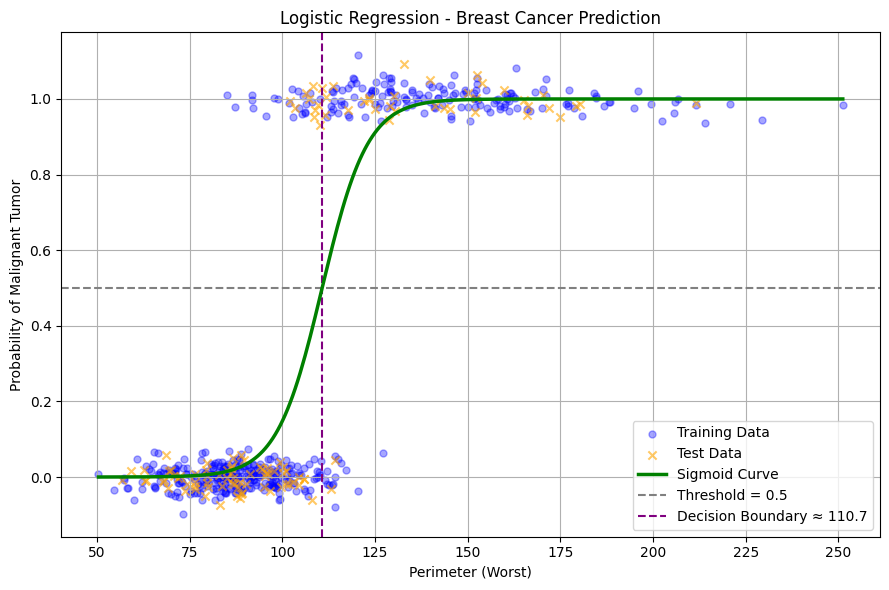

In [3]:
# Dataset: Breast Cancer Wisconsin Dataset | Path: /kaggle/input/datasets/shankarat/breast-cancer/breast cancer.csv | Target: diagnosis | Feature Selection: perimeter_worst (single feature)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = pd.read_csv("/kaggle/input/datasets/shankarat/breast-cancer/breast cancer.csv")

print("Total Rows:", data.shape[0])
print("Total Columns:", data.shape[1])
print("Features:", data.columns.tolist())

data["diagnosis"] = data["diagnosis"].map({"M": 1, "B": 0})

X = data[["perimeter_worst"]]
y = data["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

test_accuracy = accuracy_score(y_test, y_pred_test)
train_accuracy = accuracy_score(y_train, y_pred_train)

print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)
print("Train Accuracy:", train_accuracy)
print("Train Accuracy (%):", train_accuracy * 100)

feature_range = pd.DataFrame(
    np.linspace(
        data["perimeter_worst"].min(),
        data["perimeter_worst"].max(),
        300
    ),
    columns=["perimeter_worst"]
)

probability = model.predict_proba(feature_range)[:, 1]

decision_boundary = -model.intercept_[0] / model.coef_[0][0]

print("Decision Boundary:", decision_boundary)

np.random.seed(42)

jitter_train = y_train + np.random.normal(0, 0.03, size=len(y_train))
jitter_test = y_test + np.random.normal(0, 0.03, size=len(y_test))

plt.figure(figsize=(9, 6))

plt.scatter(
    X_train, jitter_train,
    label="Training Data",
    color="blue",
    alpha=0.35,
    s=25
)

plt.scatter(
    X_test, jitter_test,
    label="Test Data",
    color="orange",
    marker="x",
    alpha=0.6,
    s=35
)

plt.plot(
    feature_range,
    probability,
    linewidth=2.5,
    color="green",
    label="Sigmoid Curve",
    zorder=5
)

plt.axhline(
    0.5,
    linestyle="--",
    color="gray",
    label="Threshold = 0.5"
)

plt.axvline(
    decision_boundary,
    color="purple",
    linestyle="--",
    label=f"Decision Boundary ≈ {decision_boundary:.1f}"
)

plt.xlabel("Perimeter (Worst)")
plt.ylabel("Probability of Malignant Tumor")
plt.title("Logistic Regression - Breast Cancer Prediction")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()